In [1]:
import dataset as ds
from dataset import TensorToImg, ImgWrite, ImgRead, ImgToTensor
# dt = ds.Coco("/home/wanderer2414/coco2017/")
from torch.utils.data import DataLoader
from dataset2 import YOLODataset, collect_fn
import config
from torch import tensor, arange, float as tfloat, stack
import matplotlib.pyplot as plt
import matplotlib.patches as pat

/home/wanderer2414/.conda/envs/mtr/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/wanderer2414/MyRCNN/config.py:65: UserWarning: Argument(s) 'value' are not valid for transform PadIfNeeded
  A.PadIfNeeded(
/home/wanderer2414/.conda/envs/mtr/lib/python3.10/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/home/wanderer2414/MyRCNN/config.py:75: UserWarning: Argument(s) 'value' are not valid for transform ShiftScaleRotate
  A.ShiftScaleRotate(
/home/wanderer2414/MyRCNN/config.py:78: UserWarning: Argument(s) 'mode, cval' are not valid for transform Affine
  A.Affine(shear=15, p=0.5, mode=cv2.BORDER_CONSTANT, cval=0), # Updated from deprecated IAAAffin

In [2]:
# import MyRCNN
# import torch
# dev = "cpu"
# model = MyRCNN.Model(device=torch.device(dev))
# model.model.load_state_dict(torch.load("bbx.pth", map_location=dev))
def count_parameters(model):
        return sum(p.numel() for p in model.parameters())

# print(count_parameters(model.model.color))

In [3]:
import MyRCNN
import torch
device = config.DEVICE
model = MyRCNN.Model(bbx_epoches=0, cls_epoches=0)
model = model.to(device)
model.train()

Model(
  (model): MyRCNN(
    (mask): MaskHead()
    (color): ColorHead(
      (prepare): Sequential(
        (0): ColorDownsample()
        (1): ModePool2d()
        (2): Conv2d(3, 32, kernel_size=(1, 1), stride=(1, 1))
        (3): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=False, track_running_stats=True)
        (4): Filter()
        (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=False, track_running_stats=True)
        (6): SharedConv()
      )
      (downgrade): Sequential(
        (0): SharedConv()
      )
      (ft): Sequential(
        (0): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=False, track_running_stats=True)
        (1): SharedConv()
        (2): AvgPool2d(kernel_size=3, stride=1, padding=1)
        (3): EmphaseLocal(
          (conv): SharedConv()
        )
      )
      (interpolate): Sequential(
        (0): SharedConv()
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (feat): FeatureHead(


In [4]:
# model.Evaluate()

tensor(-0.0499, device='cuda:0', grad_fn=<MinBackward1>) tensor(0.0492, device='cuda:0', grad_fn=<MaxBackward1>)
tensor(-0.0048, device='cuda:0', grad_fn=<MinBackward1>) tensor(-0.0013, device='cuda:0', grad_fn=<MaxBackward1>)
tensor(-0.0505, device='cuda:0', grad_fn=<MinBackward1>) tensor(0.0346, device='cuda:0', grad_fn=<MaxBackward1>)
tensor(-0.0503, device='cuda:0', grad_fn=<MinBackward1>) tensor(0.0498, device='cuda:0', grad_fn=<MaxBackward1>)
tensor(-0.0045, device='cuda:0', grad_fn=<MinBackward1>) tensor(-0.0011, device='cuda:0', grad_fn=<MaxBackward1>)
tensor(0.0024, device='cuda:0', grad_fn=<MinBackward1>) tensor(0.0046, device='cuda:0', grad_fn=<MaxBackward1>)
tensor(0.0014, device='cuda:0', grad_fn=<MinBackward1>) tensor(0.0069, device='cuda:0', grad_fn=<MaxBackward1>)
tensor(-0.0495, device='cuda:0', grad_fn=<MinBackward1>) tensor(0.0501, device='cuda:0', grad_fn=<MaxBackward1>)
tensor(0.0006, device='cuda:0', grad_fn=<MinBackward1>) tensor(0.0048, device='cuda:0', grad_fn=

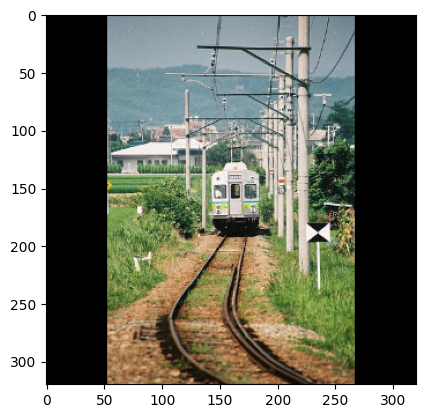

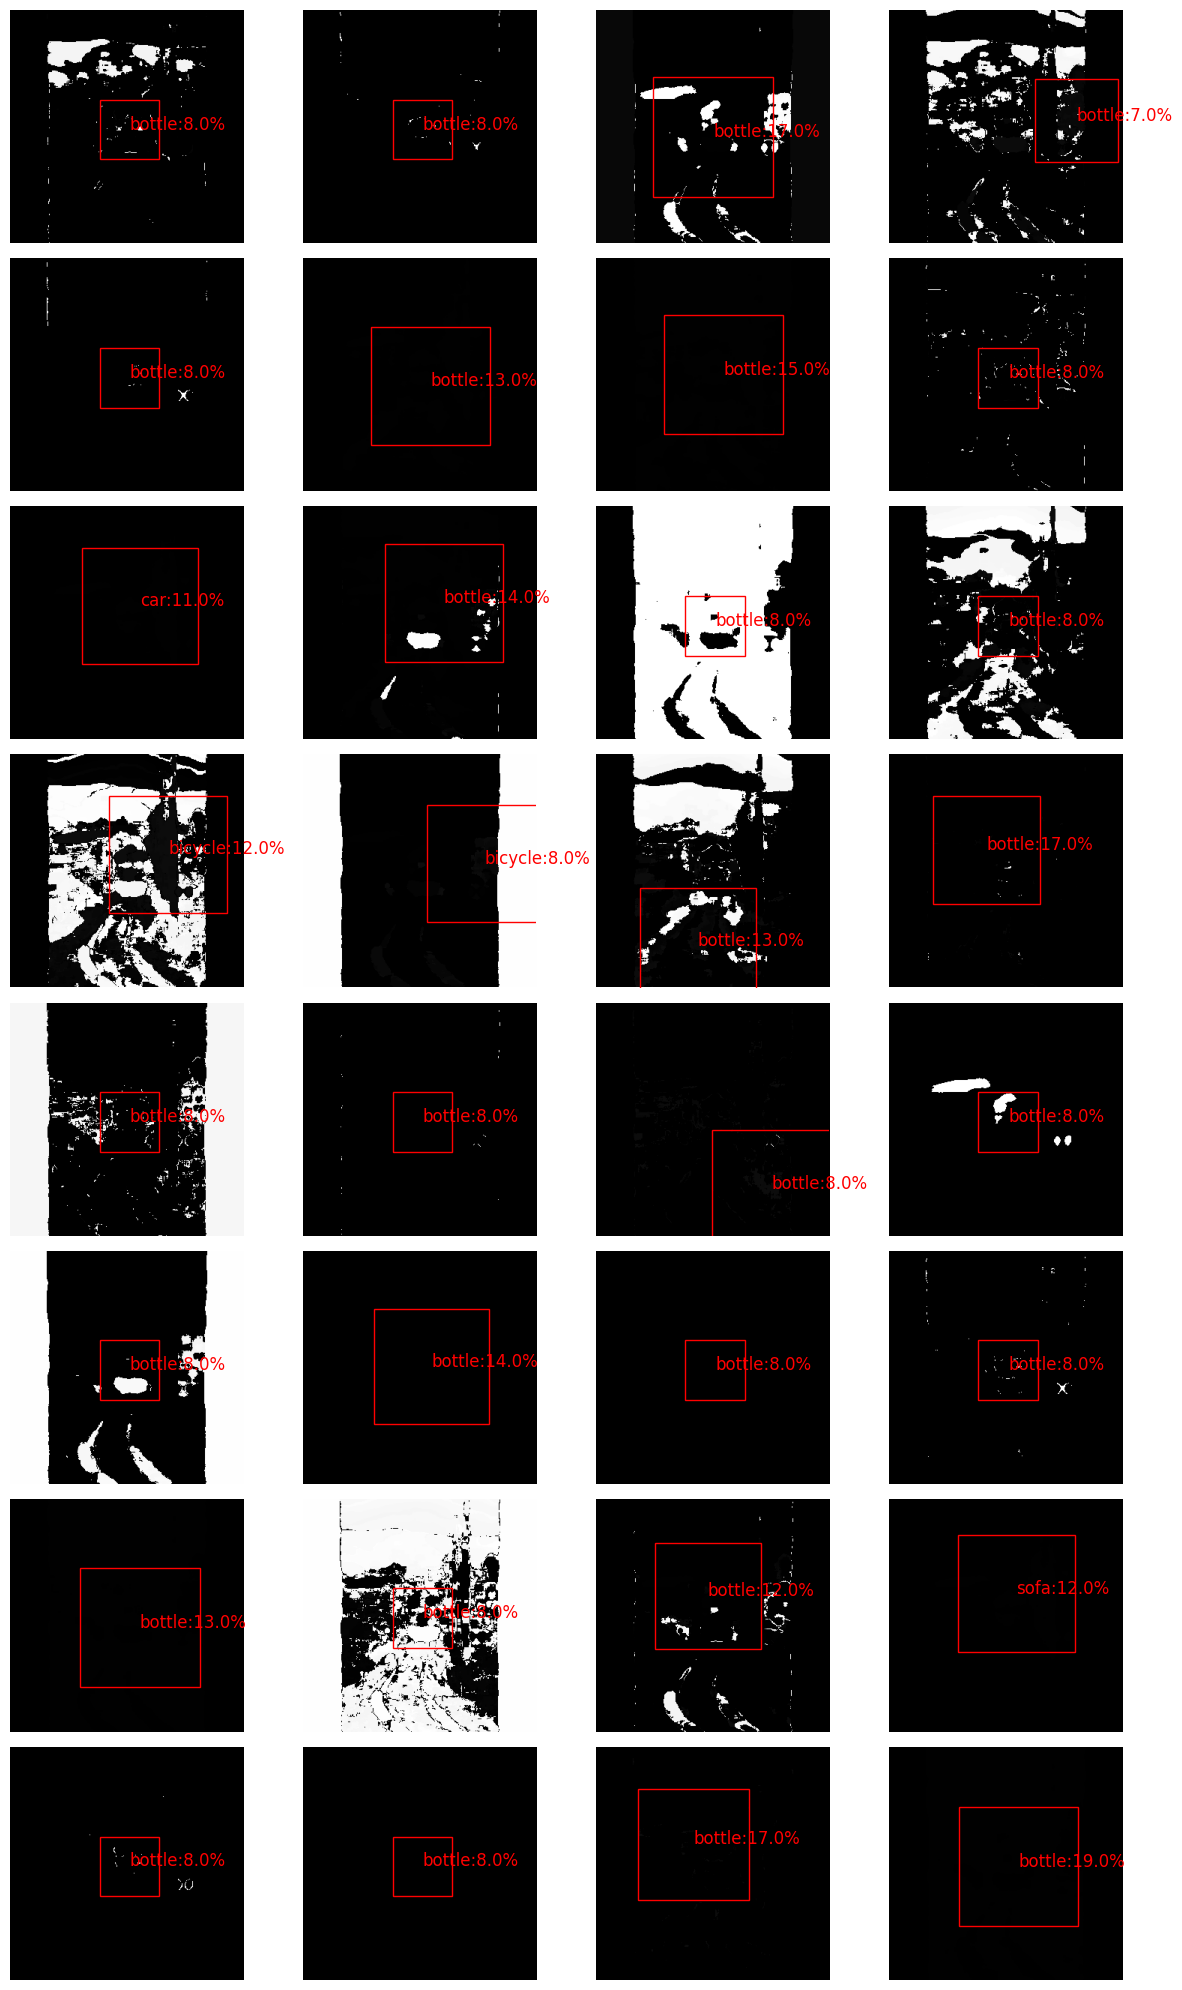

In [5]:
import matplotlib.pyplot as plt
import matplotlib.patches as pat
from torch import sigmoid, softmax, zeros, bool as tbool
from dataset import TensorToImg, ImgToTensor

model.eval()
for i, (tens,label) in enumerate(model.loader):
    if (i<0): continue
    data = tens.to(device)
    boundary, score, bbx = model.model(data)
    color = model.model.color(data)
    prep = model.model.color.prepare(data)
    sc = bbx[:, -1:]
    # print(sc)
    batch_idx = bbx[:, :1]
    bbx = bbx[:, :-1]
    cls:torch.Tensor = model.cls(boundary, score, data, bbx).squeeze()
    cls = softmax(cls, dim=-1)
    cls_value, cls_indices = cls.max(dim=-1, keepdim=True)
    sc *= cls_value
    bbx = torch.cat([sc, bbx[:, 1:], cls_indices], dim=-1)
    # x =score
    # x = color[:, 1:2,: ,:]
    # x = x.repeat(1, 3, 1, 1)
    # x = x-x.min()
    # x = x/x.max()
    x = tens
    x = TensorToImg(x.detach().cpu())
    plt.imshow(x)
    N = color.shape[1]
    fig, axes = plt.subplots(N//4, 4, figsize=(12, 20))
    cls_range = arange(20).view(20, 1, 1).expand(20, N, 1)
    for i, ax in enumerate(axes.flat):
        x = prep[:, i:i+1, :, :]
        # print(x.min(), x.max())
        x = x.repeat(1, 3, 1, 1)
        # x = x-x.min()
        # x = x/x.max()
        print(x.min(), x.max())
        # print(bbx[i].detach().cpu().numpy())
        ps, x1, y1, x2, y2, cls = bbx[i].detach().cpu().numpy()
        rect = pat.Rectangle((x1, y1), x2-x1, y2-y1, facecolor='none', edgecolor='red')
        ax.add_patch(rect)
        ax.text((x1+x2)/2, (y1+y2)/2, f"{config.PASCAL_CLASSES[cls.astype(int)]}:{(ps*100).round()}%", fontsize=12, color='red')
        ax.imshow(TensorToImg(x.detach().cpu()))
        ax.axis('off')
    plt.tight_layout()
    plt.show()
    break